# Chapter 5.5: Graph Neural Networks for Recommender Systems

## Learning Objectives

By the end of this notebook, you will be able to:

1. Construct a **user-item bipartite graph** from interaction data
2. Implement **NGCF** (Neural Graph Collaborative Filtering) with embedding propagation
3. Implement **LightGCN** from scratch with linear propagation and layer combination
4. Understand **UltraGCN** as an approximate infinite-layer propagation
5. Implement **SimGCL** contrastive learning with noise-based augmentation
6. Explain the **over-smoothing** problem and methods to mitigate it
7. Evaluate GNN-based recommenders with BPR loss and ranking metrics

## Prerequisites

- Collaborative filtering and matrix factorization (Part 1)
- Basic graph theory (adjacency matrix, degree matrix)
- PyTorch: sparse tensors, matrix operations

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part5/chapter_5.5_gnn_recsys.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://raw.githubusercontent.com/hideak1/rec_system/main/notebooks/part5/chapter_5.5_gnn_recsys.ipynb)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import random
from collections import defaultdict
import scipy.sparse as sp

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cpu


## 1. User-Item Bipartite Graph

In collaborative filtering, user-item interactions form a **bipartite graph**:

- Nodes: users and items
- Edges: interactions (clicks, purchases, ratings)

The adjacency matrix of the bipartite graph:

$$\mathbf{A} = \begin{pmatrix} \mathbf{0} & \mathbf{R} \\ \mathbf{R}^\top & \mathbf{0} \end{pmatrix}$$

where $\mathbf{R} \in \{0,1\}^{M \times N}$ is the user-item interaction matrix.

> **💡 Concept:** GNN-based recommenders propagate information along the edges of this bipartite graph. A user's embedding is refined by aggregating information from items they interacted with, and vice versa.

In [2]:
def generate_bipartite_data(n_users=500, n_items=300, n_interactions=8000, seed=42):
    """Generate synthetic user-item interaction data."""
    rng = np.random.RandomState(seed)
    
    # User and item latent factors (for generating realistic patterns)
    k = 10
    user_factors = rng.randn(n_users, k)
    item_factors = rng.randn(n_items, k)
    scores = user_factors @ item_factors.T  # (n_users, n_items)
    probs = 1 / (1 + np.exp(-scores))  # Sigmoid
    
    # Sample interactions based on probabilities
    interactions = set()
    while len(interactions) < n_interactions:
        u = rng.randint(0, n_users)
        # Sample item proportional to probability
        p = probs[u]
        p = p / p.sum()
        i = rng.choice(n_items, p=p)
        interactions.add((u, i))
    
    interactions = list(interactions)
    users = [x[0] for x in interactions]
    items = [x[1] for x in interactions]
    
    return users, items, n_users, n_items

users, items, N_USERS, N_ITEMS = generate_bipartite_data()

# Build user->items and item->users mappings
user_items = defaultdict(set)
item_users = defaultdict(set)
for u, i in zip(users, items):
    user_items[u].add(i)
    item_users[i].add(u)

print(f"Users: {N_USERS}, Items: {N_ITEMS}, Interactions: {len(users)}")
print(f"Density: {len(users) / (N_USERS * N_ITEMS) * 100:.2f}%")
print(f"Avg items/user: {np.mean([len(v) for v in user_items.values()]):.1f}")
print(f"Avg users/item: {np.mean([len(v) for v in item_users.values()]):.1f}")

Users: 500, Items: 300, Interactions: 8000
Density: 5.33%
Avg items/user: 16.0
Avg users/item: 26.7


In [3]:
def build_norm_adj_matrix(users, items, n_users, n_items):
    """
    Build the normalized adjacency matrix for the bipartite graph.
    Returns: sparse (n_users+n_items, n_users+n_items) matrix
    
    Normalization: D^{-1/2} A D^{-1/2} (symmetric normalization)
    """
    n_nodes = n_users + n_items
    
    # Build sparse interaction matrix R
    row = np.array(users)
    col = np.array(items) + n_users  # Offset items
    data = np.ones(len(users))
    
    # Build full adjacency (symmetric)
    adj = sp.coo_matrix(
        (np.concatenate([data, data]),
         (np.concatenate([row, col]), np.concatenate([col, row]))),
        shape=(n_nodes, n_nodes)
    ).tocsr()
    
    # Symmetric normalization: D^{-1/2} A D^{-1/2}
    degrees = np.array(adj.sum(axis=1)).flatten()
    d_inv_sqrt = np.power(degrees, -0.5)
    d_inv_sqrt[np.isinf(d_inv_sqrt)] = 0.0
    D_inv_sqrt = sp.diags(d_inv_sqrt)
    
    norm_adj = D_inv_sqrt @ adj @ D_inv_sqrt
    
    # Convert to PyTorch sparse tensor
    norm_adj = norm_adj.tocoo()
    indices = torch.tensor(np.vstack([norm_adj.row, norm_adj.col]), dtype=torch.long)
    values = torch.tensor(norm_adj.data, dtype=torch.float)
    shape = torch.Size(norm_adj.shape)
    
    return torch.sparse_coo_tensor(indices, values, shape)

norm_adj = build_norm_adj_matrix(users, items, N_USERS, N_ITEMS)
print(f"Normalized adjacency matrix shape: {norm_adj.shape}")
print(f"Number of non-zeros: {norm_adj._nnz()}")

Normalized adjacency matrix shape: torch.Size([800, 800])
Number of non-zeros: 16000


## 2. NGCF: Neural Graph Collaborative Filtering

**NGCF** (Wang et al., SIGIR 2019) propagates embeddings on the user-item graph with learnable transformations:

$$\mathbf{e}_u^{(l+1)} = \sigma\left(\mathbf{W}_1 \mathbf{e}_u^{(l)} + \sum_{i \in \mathcal{N}_u} \frac{1}{\sqrt{|\mathcal{N}_u||\mathcal{N}_i|}} \left(\mathbf{W}_1 \mathbf{e}_i^{(l)} + \mathbf{W}_2 (\mathbf{e}_i^{(l)} \odot \mathbf{e}_u^{(l)})\right)\right)$$

Key components:
- $\mathbf{W}_1$: linear transformation for neighbor aggregation
- $\mathbf{W}_2$: captures feature interactions between user and item
- $\sigma$: activation function (LeakyReLU)

> **⚠️ Common Pitfall:** NGCF's non-linear transformations and feature interaction terms add complexity but were later shown to provide diminishing returns. LightGCN removes them entirely.

In [4]:
class NGCF(nn.Module):
    """Neural Graph Collaborative Filtering (Wang et al., 2019)."""
    
    def __init__(self, n_users, n_items, embed_dim=64, n_layers=3, dropout=0.1):
        super().__init__()
        self.n_users = n_users
        self.n_items = n_items
        self.n_layers = n_layers
        
        self.user_emb = nn.Embedding(n_users, embed_dim)
        self.item_emb = nn.Embedding(n_items, embed_dim)
        
        # Transformation matrices for each layer
        self.W1_layers = nn.ModuleList([
            nn.Linear(embed_dim, embed_dim) for _ in range(n_layers)
        ])
        self.W2_layers = nn.ModuleList([
            nn.Linear(embed_dim, embed_dim) for _ in range(n_layers)
        ])
        self.dropout = nn.Dropout(dropout)
        
        nn.init.xavier_uniform_(self.user_emb.weight)
        nn.init.xavier_uniform_(self.item_emb.weight)
    
    def forward(self, norm_adj):
        """Propagate embeddings on the graph."""
        # Initial embeddings
        all_emb = torch.cat([self.user_emb.weight, self.item_emb.weight], dim=0)
        
        layer_embs = [all_emb]
        
        for l in range(self.n_layers):
            # Neighborhood aggregation
            neighbor_emb = torch.sparse.mm(norm_adj, all_emb)  # D^-1/2 A D^-1/2 @ E
            
            # NGCF propagation: W1*e_i + W2*(e_i . e_u) approximated by:
            # W1 * neighbor + W2 * (neighbor * self)
            sum_emb = self.W1_layers[l](neighbor_emb + all_emb)
            interaction_emb = self.W2_layers[l](neighbor_emb * all_emb)
            
            all_emb = F.leaky_relu(sum_emb + interaction_emb, negative_slope=0.2)
            all_emb = self.dropout(all_emb)
            all_emb = F.normalize(all_emb, dim=-1)
            layer_embs.append(all_emb)
        
        # Concatenate all layer embeddings
        final_emb = torch.cat(layer_embs, dim=-1)  # (n_users+n_items, (L+1)*embed_dim)
        user_embs = final_emb[:self.n_users]
        item_embs = final_emb[self.n_users:]
        
        return user_embs, item_embs

ngcf = NGCF(N_USERS, N_ITEMS, embed_dim=64, n_layers=3)
u_emb, i_emb = ngcf(norm_adj)
print(f"User embeddings: {u_emb.shape}, Item embeddings: {i_emb.shape}")

User embeddings: torch.Size([500, 256]), Item embeddings: torch.Size([300, 256])


## 3. LightGCN: Simplified Graph Convolution

**LightGCN** (He et al., SIGIR 2020) makes a crucial simplification: **remove all learnable transformations** from the graph convolution.

Propagation rule:
$$\mathbf{e}_u^{(l+1)} = \sum_{i \in \mathcal{N}_u} \frac{1}{\sqrt{|\mathcal{N}_u|} \sqrt{|\mathcal{N}_i|}} \mathbf{e}_i^{(l)}$$

In matrix form:
$$\mathbf{E}^{(l+1)} = \tilde{\mathbf{A}} \mathbf{E}^{(l)}$$

where $\tilde{\mathbf{A}} = \mathbf{D}^{-1/2} \mathbf{A} \mathbf{D}^{-1/2}$.

Final embeddings are a **weighted combination** of all layers:
$$\mathbf{e}_u = \sum_{l=0}^{L} \alpha_l \mathbf{e}_u^{(l)}$$

Typically $\alpha_l = \frac{1}{L+1}$ (uniform).

> **💡 Concept:** LightGCN shows that the nonlinear transformations in NGCF actually *hurt* performance. The graph structure itself provides enough inductive bias — the only learnable parameters are the initial embeddings.

In [5]:
class LightGCN(nn.Module):
    """LightGCN: Simplifying and Powering GCN for Recommendation (He et al., 2020)."""
    
    def __init__(self, n_users, n_items, embed_dim=64, n_layers=3):
        super().__init__()
        self.n_users = n_users
        self.n_items = n_items
        self.n_layers = n_layers
        self.embed_dim = embed_dim
        
        # Only learnable parameters: initial embeddings
        self.user_emb = nn.Embedding(n_users, embed_dim)
        self.item_emb = nn.Embedding(n_items, embed_dim)
        
        nn.init.xavier_uniform_(self.user_emb.weight)
        nn.init.xavier_uniform_(self.item_emb.weight)
    
    def forward(self, norm_adj):
        """
        Propagate embeddings through L layers of graph convolution.
        Returns: (user_embs, item_embs) after layer combination.
        """
        all_emb = torch.cat([self.user_emb.weight, self.item_emb.weight], dim=0)
        layer_embs = [all_emb]
        
        for l in range(self.n_layers):
            all_emb = torch.sparse.mm(norm_adj, all_emb)
            layer_embs.append(all_emb)
        
        # Layer combination: uniform average
        final_emb = torch.stack(layer_embs, dim=0).mean(dim=0)
        
        user_embs = final_emb[:self.n_users]
        item_embs = final_emb[self.n_users:]
        
        return user_embs, item_embs
    
    def predict(self, norm_adj, user_ids, item_ids):
        """Score user-item pairs."""
        user_embs, item_embs = self.forward(norm_adj)
        u = user_embs[user_ids]  # (batch, embed_dim)
        i = item_embs[item_ids]  # (batch, embed_dim)
        return (u * i).sum(dim=-1)  # (batch,) dot product scores

lgcn = LightGCN(N_USERS, N_ITEMS, embed_dim=64, n_layers=3)
u_emb, i_emb = lgcn(norm_adj)
print(f"LightGCN — User: {u_emb.shape}, Item: {i_emb.shape}")
print(f"Parameters: {sum(p.numel() for p in lgcn.parameters()):,} (only embeddings!)")

LightGCN — User: torch.Size([500, 64]), Item: torch.Size([300, 64])
Parameters: 51,200 (only embeddings!)


## 4. Training LightGCN with BPR Loss

In [6]:
class BPRDataset(Dataset):
    """BPR training dataset: (user, pos_item, neg_item) triplets."""
    
    def __init__(self, users, items, n_items, user_items_dict):
        self.interactions = list(zip(users, items))
        self.n_items = n_items
        self.user_items = user_items_dict
    
    def __len__(self):
        return len(self.interactions)
    
    def __getitem__(self, idx):
        user, pos_item = self.interactions[idx]
        # Sample negative item
        neg_item = random.randint(0, self.n_items - 1)
        while neg_item in self.user_items[user]:
            neg_item = random.randint(0, self.n_items - 1)
        return (
            torch.tensor(user, dtype=torch.long),
            torch.tensor(pos_item, dtype=torch.long),
            torch.tensor(neg_item, dtype=torch.long),
        )

# Train/test split: leave last interaction per user for test
train_users, train_items = [], []
test_pairs = []

for u, i_set in user_items.items():
    i_list = list(i_set)
    if len(i_list) > 1:
        test_pairs.append((u, i_list[-1]))
        for i in i_list[:-1]:
            train_users.append(u)
            train_items.append(i)
    else:
        for i in i_list:
            train_users.append(u)
            train_items.append(i)

# Rebuild adj matrix for training data
train_norm_adj = build_norm_adj_matrix(train_users, train_items, N_USERS, N_ITEMS)

train_user_items = defaultdict(set)
for u, i in zip(train_users, train_items):
    train_user_items[u].add(i)

train_dataset = BPRDataset(train_users, train_items, N_ITEMS, train_user_items)
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)

print(f"Train interactions: {len(train_users)}, Test pairs: {len(test_pairs)}")

Train interactions: 7500, Test pairs: 500


In [7]:
def train_lightgcn(model, norm_adj, train_loader, test_pairs, train_user_items,
                   n_items, n_epochs=20, lr=0.001, reg_weight=1e-4):
    """Train LightGCN with BPR loss."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"loss": [], "hr20": []}
    
    for epoch in range(n_epochs):
        model.train()
        total_loss = 0
        n_batches = 0
        
        for user, pos_item, neg_item in train_loader:
            user_embs, item_embs = model(norm_adj)
            
            u_emb = user_embs[user]
            pos_emb = item_embs[pos_item]
            neg_emb = item_embs[neg_item]
            
            pos_scores = (u_emb * pos_emb).sum(dim=-1)
            neg_scores = (u_emb * neg_emb).sum(dim=-1)
            
            # BPR loss
            bpr_loss = -torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-8).mean()
            
            # L2 regularization on embeddings
            reg_loss = reg_weight * (
                model.user_emb.weight[user].norm(2).pow(2) +
                model.item_emb.weight[pos_item].norm(2).pow(2) +
                model.item_emb.weight[neg_item].norm(2).pow(2)
            ) / user.size(0)
            
            loss = bpr_loss + reg_loss
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            n_batches += 1
        
        avg_loss = total_loss / n_batches
        history["loss"].append(avg_loss)
        
        # Evaluate every 5 epochs
        if (epoch + 1) % 5 == 0:
            hr20 = evaluate_lightgcn(model, norm_adj, test_pairs, train_user_items, n_items)
            history["hr20"].append(hr20)
            print(f"Epoch {epoch+1}/{n_epochs} — Loss: {avg_loss:.4f}, HR@20: {hr20:.4f}")
    
    return history

@torch.no_grad()
def evaluate_lightgcn(model, norm_adj, test_pairs, train_user_items, n_items, k=20):
    model.eval()
    user_embs, item_embs = model(norm_adj)
    
    hits = 0
    for u, true_item in test_pairs:
        scores = user_embs[u] @ item_embs.T  # (n_items,)
        # Mask training items
        for train_i in train_user_items[u]:
            scores[train_i] = -float("inf")
        _, topk = scores.topk(k)
        if true_item in topk.tolist():
            hits += 1
    return hits / len(test_pairs)

torch.manual_seed(SEED)
lgcn_model = LightGCN(N_USERS, N_ITEMS, embed_dim=64, n_layers=3)
lgcn_history = train_lightgcn(
    lgcn_model, train_norm_adj, train_loader, test_pairs, train_user_items, N_ITEMS,
    n_epochs=20, lr=0.001
)

Epoch 5/20 — Loss: 0.6900, HR@20: 0.0580


Epoch 10/20 — Loss: 0.6843, HR@20: 0.0440


Epoch 15/20 — Loss: 0.6733, HR@20: 0.0260


Epoch 20/20 — Loss: 0.6546, HR@20: 0.0260


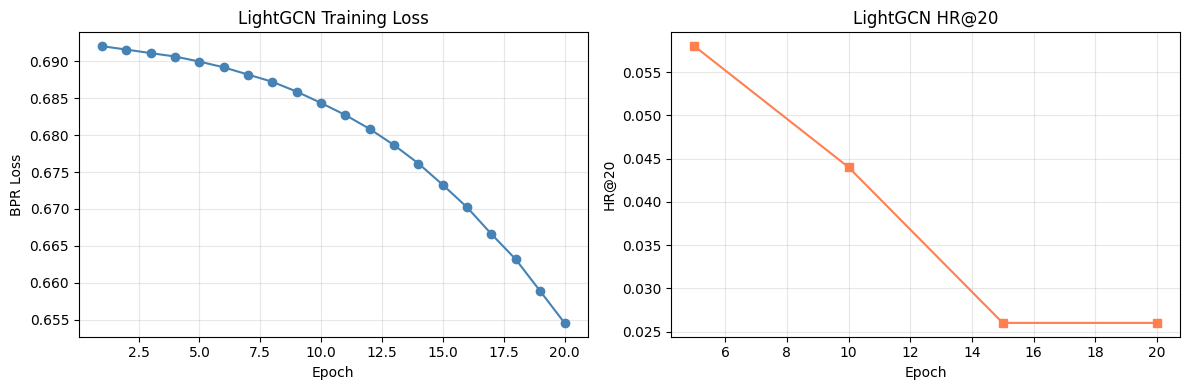

In [8]:
# Training visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, len(lgcn_history["loss"]) + 1), lgcn_history["loss"],
             marker="o", color="steelblue")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("BPR Loss")
axes[0].set_title("LightGCN Training Loss")
axes[0].grid(True, alpha=0.3)

eval_epochs = list(range(5, 21, 5))
axes[1].plot(eval_epochs, lgcn_history["hr20"], marker="s", color="coral")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("HR@20")
axes[1].set_title("LightGCN HR@20")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. UltraGCN: Approximate Infinite-Layer Propagation

**UltraGCN** (Mao et al., CIKM 2021) skips explicit graph convolution entirely. Instead, it approximates the result of infinite-layer propagation using a **convergence constraint loss**.

The key insight: as $L \to \infty$, LightGCN converges to the eigenvectors of $\tilde{\mathbf{A}}$. UltraGCN directly optimizes for this limit.

$$\mathcal{L}_{\text{UltraGCN}} = \mathcal{L}_{\text{BPR}} + \lambda_1 \sum_{(u,i)} w_{ui} \|\mathbf{e}_u - \mathbf{e}_i\|^2 + \lambda_2 \sum_{(i,j)} s_{ij} \|\mathbf{e}_i - \mathbf{e}_j\|^2$$

where $w_{ui}$ are user-item edge weights and $s_{ij}$ are item-item similarity weights.

> **🔑 Pro Tip:** UltraGCN is much faster than LightGCN at training time since it avoids repeated sparse matrix multiplications. The trade-off is more complex loss computation.

In [9]:
class UltraGCN(nn.Module):
    """Simplified UltraGCN (Mao et al., 2021)."""
    
    def __init__(self, n_users, n_items, embed_dim=64):
        super().__init__()
        self.user_emb = nn.Embedding(n_users, embed_dim)
        self.item_emb = nn.Embedding(n_items, embed_dim)
        nn.init.xavier_uniform_(self.user_emb.weight)
        nn.init.xavier_uniform_(self.item_emb.weight)
    
    def forward(self, user_ids, item_ids):
        u = self.user_emb(user_ids)
        i = self.item_emb(item_ids)
        return (u * i).sum(dim=-1)
    
    def constraint_loss(self, user_ids, pos_item_ids, user_items_dict, n_items,
                        n_neighbors=5):
        """Convergence constraint: pull interacted user-item pairs close."""
        u_emb = self.user_emb(user_ids)  # (batch, dim)
        pos_emb = self.item_emb(pos_item_ids)  # (batch, dim)
        
        # User-item constraint
        ui_loss = ((u_emb - pos_emb) ** 2).sum(dim=-1).mean()
        
        return ui_loss

ultragcn = UltraGCN(N_USERS, N_ITEMS, embed_dim=64)
test_u = torch.tensor([0, 1, 2])
test_i = torch.tensor([5, 10, 15])
scores = ultragcn(test_u, test_i)
print(f"UltraGCN scores: {scores.detach().numpy()}")

UltraGCN scores: [-0.02107469 -0.0176257  -0.0081598 ]


## 6. SimGCL: Contrastive Learning with Noise Augmentation

**SimGCL** (Yu et al., SIGIR 2022) adds random noise to embeddings as augmentation for contrastive learning:

$$\tilde{\mathbf{e}}_u^{(l)} = \mathbf{e}_u^{(l)} + \epsilon \cdot \Delta_u^{(l)}$$

where $\Delta_u^{(l)}$ is a random perturbation vector and $\epsilon$ controls noise magnitude.

This is **simpler than graph augmentation** (dropping edges/nodes) and often more effective.

In [10]:
class SimGCL(nn.Module):
    """SimGCL: Simple Graph Contrastive Learning (Yu et al., 2022)."""
    
    def __init__(self, n_users, n_items, embed_dim=64, n_layers=3, noise_eps=0.1):
        super().__init__()
        self.n_users = n_users
        self.n_items = n_items
        self.n_layers = n_layers
        self.noise_eps = noise_eps
        
        self.user_emb = nn.Embedding(n_users, embed_dim)
        self.item_emb = nn.Embedding(n_items, embed_dim)
        nn.init.xavier_uniform_(self.user_emb.weight)
        nn.init.xavier_uniform_(self.item_emb.weight)
    
    def _propagate(self, norm_adj, add_noise=False):
        """LightGCN-style propagation, optionally with noise."""
        all_emb = torch.cat([self.user_emb.weight, self.item_emb.weight], dim=0)
        layer_embs = [all_emb]
        
        for _ in range(self.n_layers):
            all_emb = torch.sparse.mm(norm_adj, all_emb)
            if add_noise:
                noise = torch.randn_like(all_emb)
                noise = F.normalize(noise, dim=-1) * self.noise_eps
                all_emb = all_emb + noise
            layer_embs.append(all_emb)
        
        final_emb = torch.stack(layer_embs, dim=0).mean(dim=0)
        return final_emb[:self.n_users], final_emb[self.n_users:]
    
    def forward(self, norm_adj):
        """Clean forward pass."""
        return self._propagate(norm_adj, add_noise=False)
    
    def get_contrastive_views(self, norm_adj):
        """Get two noisy views for contrastive learning."""
        u1, i1 = self._propagate(norm_adj, add_noise=True)
        u2, i2 = self._propagate(norm_adj, add_noise=True)
        return (u1, i1), (u2, i2)

simgcl = SimGCL(N_USERS, N_ITEMS, embed_dim=64, noise_eps=0.1)
u_clean, i_clean = simgcl(train_norm_adj)
(u_v1, i_v1), (u_v2, i_v2) = simgcl.get_contrastive_views(train_norm_adj)
print(f"Clean user emb: {u_clean.shape}")
print(f"View 1 user emb: {u_v1.shape}")
# Check that views are different
diff = (u_v1 - u_v2).norm(dim=-1).mean()
print(f"Avg L2 distance between views: {diff.item():.4f}")

Clean user emb: torch.Size([500, 64])
View 1 user emb: torch.Size([500, 64])
Avg L2 distance between views: 0.0623


## 7. Over-Smoothing Problem

As the number of GCN layers increases, all node embeddings converge to the same value. This is **over-smoothing**.

**Quantifying over-smoothing**: We measure the average pairwise cosine similarity between user embeddings at each layer.

> **⚠️ Common Pitfall:** Using too many GCN layers (> 3-4) typically hurts performance due to over-smoothing. LightGCN's layer combination partially mitigates this by preserving earlier (less smooth) representations.

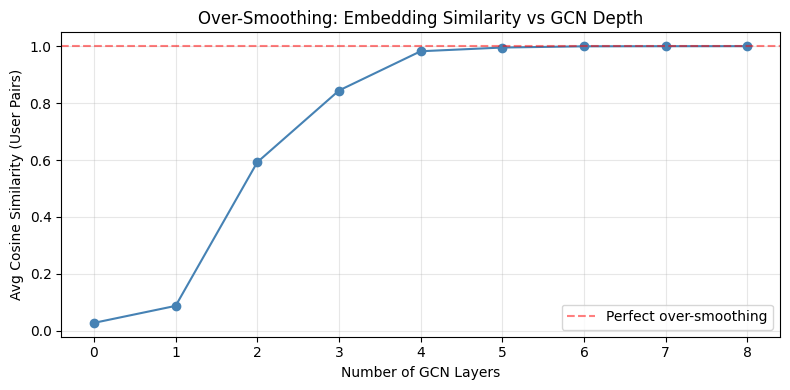

Cosine similarity per layer:
  Layer 0: 0.0277
  Layer 1: 0.0874
  Layer 2: 0.5923
  Layer 3: 0.8442
  Layer 4: 0.9821
  Layer 5: 0.9952
  Layer 6: 0.9995
  Layer 7: 0.9999
  Layer 8: 1.0000


In [11]:
@torch.no_grad()
def measure_over_smoothing(norm_adj, user_emb, item_emb, max_layers=8):
    """Measure embedding similarity at each propagation layer."""
    all_emb = torch.cat([user_emb, item_emb], dim=0)
    n_users = user_emb.size(0)
    
    avg_cosines = []
    
    for l in range(max_layers + 1):
        # Sample 200 random user pairs for efficiency
        user_embs = all_emb[:n_users]
        idx1 = torch.randint(0, n_users, (200,))
        idx2 = torch.randint(0, n_users, (200,))
        cos_sim = F.cosine_similarity(user_embs[idx1], user_embs[idx2], dim=-1)
        avg_cosines.append(cos_sim.mean().item())
        
        if l < max_layers:
            all_emb = torch.sparse.mm(norm_adj, all_emb)
    
    return avg_cosines

cosines = measure_over_smoothing(
    train_norm_adj,
    lgcn_model.user_emb.weight.detach(),
    lgcn_model.item_emb.weight.detach(),
    max_layers=8
)

plt.figure(figsize=(8, 4))
plt.plot(range(len(cosines)), cosines, marker="o", color="steelblue")
plt.axhline(y=1.0, color="red", linestyle="--", alpha=0.5, label="Perfect over-smoothing")
plt.xlabel("Number of GCN Layers")
plt.ylabel("Avg Cosine Similarity (User Pairs)")
plt.title("Over-Smoothing: Embedding Similarity vs GCN Depth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Cosine similarity per layer:")
for l, c in enumerate(cosines):
    print(f"  Layer {l}: {c:.4f}")

## 8. DirectAU: Alignment and Uniformity

**DirectAU** (Wang et al., KDD 2022) proposes optimizing two properties directly:

- **Alignment**: Positive pairs should be close: $\mathcal{L}_{\text{align}} = \mathbb{E}_{(u,i) \sim p_{\text{pos}}} \|\mathbf{e}_u - \mathbf{e}_i\|^2$
- **Uniformity**: Embeddings should be uniformly distributed on the hypersphere: $\mathcal{L}_{\text{uniform}} = \log \mathbb{E}_{(x,y) \sim p_{\text{all}}} e^{-2\|\mathbf{x} - \mathbf{y}\|^2}$

In [12]:
def alignment_loss(user_embs, item_embs):
    """Alignment: positive pairs should be close."""
    user_embs = F.normalize(user_embs, dim=-1)
    item_embs = F.normalize(item_embs, dim=-1)
    return ((user_embs - item_embs) ** 2).sum(dim=-1).mean()

def uniformity_loss(embs, t=2.0):
    """Uniformity: embeddings should be spread out."""
    embs = F.normalize(embs, dim=-1)
    # Pairwise squared distances
    pdist = torch.cdist(embs, embs, p=2).pow(2)
    return pdist.mul(-t).exp().mean().log()

# Measure alignment and uniformity of trained LightGCN
lgcn_model.eval()
with torch.no_grad():
    u_e, i_e = lgcn_model(train_norm_adj)
    # Sample some positive pairs
    sample_idx = random.sample(range(len(train_users)), 500)
    su = torch.tensor([train_users[i] for i in sample_idx])
    si = torch.tensor([train_items[i] for i in sample_idx])
    
    align = alignment_loss(u_e[su], i_e[si]).item()
    uniform_u = uniformity_loss(u_e[:200]).item()
    uniform_i = uniformity_loss(i_e[:200]).item()

print(f"Alignment loss: {align:.4f} (lower = better aligned)")
print(f"Uniformity (users): {uniform_u:.4f} (lower = more uniform)")
print(f"Uniformity (items): {uniform_i:.4f}")

Alignment loss: 1.1255 (lower = better aligned)
Uniformity (users): -3.1346 (lower = more uniform)
Uniformity (items): -3.2226


## 9. Layer-wise Embedding Visualization

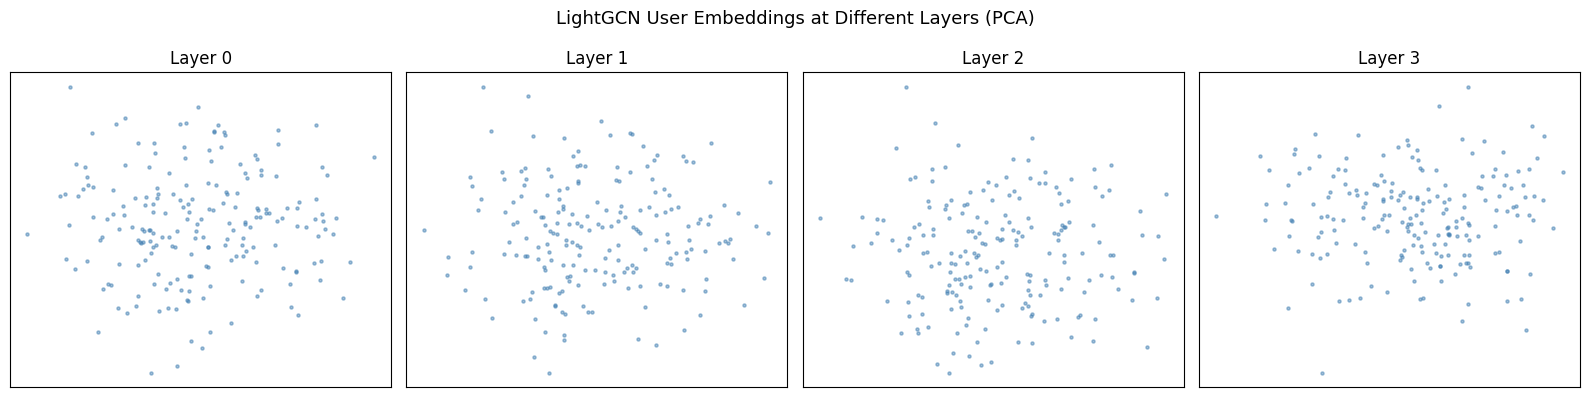

In [13]:
@torch.no_grad()
def get_layer_embeddings(model, norm_adj):
    """Get user embeddings at each LightGCN layer."""
    all_emb = torch.cat([model.user_emb.weight, model.item_emb.weight], dim=0)
    layer_embs = [all_emb[:model.n_users].clone()]
    
    for _ in range(model.n_layers):
        all_emb = torch.sparse.mm(norm_adj, all_emb)
        layer_embs.append(all_emb[:model.n_users].clone())
    
    return layer_embs

layer_embs = get_layer_embeddings(lgcn_model, train_norm_adj)

# Reduce to 2D via PCA for visualization
from torch.linalg import svd

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
n_sample = 200
sample_users = list(range(n_sample))

for l, (emb, ax) in enumerate(zip(layer_embs, axes)):
    e = emb[sample_users]
    e = e - e.mean(dim=0)
    U, S, V = svd(e)
    proj = (e @ V[:2].T).numpy()
    ax.scatter(proj[:, 0], proj[:, 1], s=5, alpha=0.5, color="steelblue")
    ax.set_title(f"Layer {l}")
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle("LightGCN User Embeddings at Different Layers (PCA)", fontsize=13)
plt.tight_layout()
plt.show()

## 10. Exercises

### 🏋️ Exercise 1: Implement LightGCN from Scratch on Synthetic Graph

In [14]:
# 🏋️ Exercise 1: LightGCN from Scratch
#
# Implement LightGCN without using the class above.
# Requirements:
# 1. Build the normalized adjacency matrix from scratch
# 2. Implement the propagation loop
# 3. Implement BPR training
# 4. Evaluate with HR@20 and NDCG@20

class LightGCNScratch(nn.Module):
    def __init__(self, n_users, n_items, embed_dim=64, n_layers=3):
        super().__init__()
        # TODO: Implement
        pass
    
    def forward(self, adj_matrix):
        # TODO: Implement
        # 1. Concatenate user and item embeddings
        # 2. Propagate L times through adj_matrix
        # 3. Average all layer embeddings
        # 4. Split back into user and item embeddings
        pass

def compute_ndcg_at_k(model, norm_adj, test_pairs, train_user_items, n_items, k=20):
    # TODO: Implement NDCG@K
    # NDCG@K = DCG@K / IDCG@K
    # DCG@K = sum_{i=1}^{K} (2^{rel_i} - 1) / log2(i+1)
    # For implicit feedback, rel_i = 1 if item is relevant, 0 otherwise
    pass

### 🏋️ Exercise 2: Compare Number of GCN Layers

In [15]:
# 🏋️ Exercise 2: Layer Sensitivity
#
# Train LightGCN with 1, 2, 3, 4, 5, and 6 layers.
# Plot HR@20 vs number of layers.
# Expected: performance peaks around 2-3 layers, then degrades.

# TODO:
# for n_layers in [1, 2, 3, 4, 5, 6]:
#     model = LightGCN(N_USERS, N_ITEMS, embed_dim=64, n_layers=n_layers)
#     train and evaluate...
pass

### 🏋️ Exercise 3: Implement SimGCL Training

In [16]:
# 🏋️ Exercise 3: SimGCL Training
#
# Train SimGCL with joint BPR + InfoNCE loss.

def train_simgcl(model, norm_adj, train_loader, n_epochs=20, lr=0.001,
                 cl_weight=0.1, temperature=0.2):
    # TODO: Implement
    # For each batch:
    # 1. Get clean embeddings for BPR loss
    # 2. Get two noisy views for contrastive loss
    # 3. Compute BPR loss + cl_weight * InfoNCE loss
    # 4. InfoNCE: for each user in batch, positive = same user in other view
    #    negatives = other users in the batch
    pass

# torch.manual_seed(SEED)
# simgcl_model = SimGCL(N_USERS, N_ITEMS, embed_dim=64, noise_eps=0.1)
# train_simgcl(simgcl_model, train_norm_adj, train_loader)

## Summary

| Method | Year | Key Idea | Trainable Params |
|--------|------|----------|------------------|
| NGCF | 2019 | Nonlinear propagation + feature interaction | Embeddings + W1, W2 per layer |
| LightGCN | 2020 | Linear propagation + layer combination | Embeddings only |
| UltraGCN | 2021 | Skip propagation, convergence constraint | Embeddings only |
| SimGCL | 2022 | Noise-based contrastive augmentation | Embeddings only |
| LightGCL | 2023 | SVD-based contrastive augmentation | Embeddings only |
| DirectAU | 2022 | Alignment + uniformity loss | Embeddings only |

**Key Takeaways:**
1. GNN-based recommenders exploit the graph structure of user-item interactions
2. LightGCN's key insight: nonlinear transformations are unnecessary for recommendation
3. Over-smoothing limits GCN depth to 2-4 layers in practice
4. Contrastive learning (SimGCL) further improves GNN-based rec
5. Alignment and uniformity provide useful diagnostic metrics
6. Next chapter: **Knowledge Graphs** for enhanced recommendation